# Lecture 7: A/B Testing, Causality

---

## Outline

* [A/B Testing](#A/B-Testing)
* [Digital Experiments](#Digital-Experiments)
* [Hypothesis Testing Review](#Hypothesis-Testing-Review)

---

## Set Up the Notebook

In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

---

## A/B Testing

---

### Comparing Two Samples

<img src="a_b_testing_billboard.jpg" width=60% alt="A billboard near Palo Alto referencing A/B testing.">

* Compare values of sampled individuals in Group A with values of sampled individuals in Group B.
* Question: Do the two sets of values come from the same underlying distribution?
* Answering this question by performing a statistical test is called A/B testing.

---

### Smoking and Birth Weight


### Comparing Two Samples

* Compare values of sampled individuals in `Group A` with values of sampled individuals in `Group B`.


### Example: Smoking, Ladies, & Babies

The table births contains the following variables for 1,174 mother-baby pairs: 

* Random samples of mothers of newborns.

Compare:
    
    (A) Birth weights of babies of mothers who smoked during pregnancy
    
    (B) Birth weights of babies of mothers who didn't smoke

 * Load the data in `baby.csv`. This data contains information on 1174 pregnancies and was part of a larger study of all the births form 1960 to 1967 among women in the Kaiser Foundation Health Plan in Oakland, California.
* Explore the relationship between the values of `'Maternal Smoker'` and `'Birth Weight'`.                                                 


In [2]:
births = Table().read_table("baby.csv")
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


## Comparing Two Samples

In [3]:
smoking_and_birthweight = births.select('Maternal Smoker', 'Birth Weight')
smoking_and_birthweight

Maternal Smoker,Birth Weight
False,120
False,113
True,128
True,108
False,136
False,138
False,132
False,120
True,143
False,140


In [4]:
smoking_and_birthweight.group('Maternal Smoker')


Maternal Smoker,count
False,715
True,459


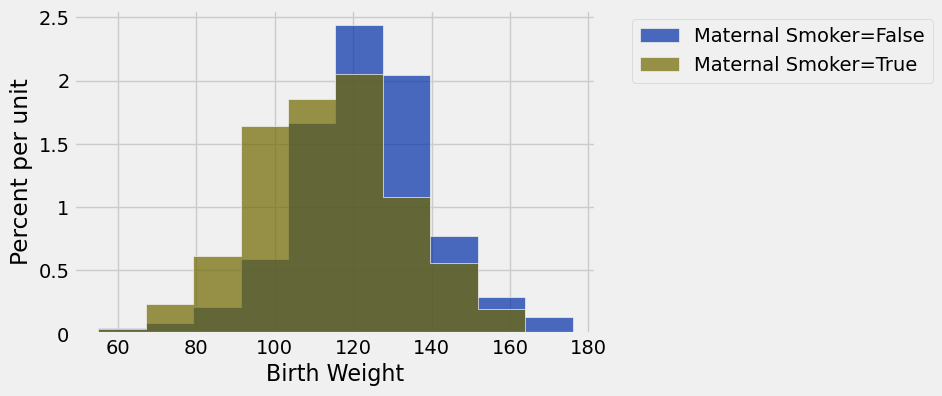

In [5]:
smoking_and_birthweight.hist('Birth Weight', group = 'Maternal Smoker')

In [7]:
means_table = smoking_and_birthweight.group('Maternal Smoker', np.mean)
means_table

Maternal Smoker,Birth Weight mean
False,123.085
True,113.819


---

### The Groups and the Question

* Sample of mothers of newborns. Compare:
    * Birth weights of babies of mothers who didn't smoke
    * Birth weights of babies of mothers who smoked during pregnancy 
* Question: Could the differences we are observing be due to chance alone?


---

### Hypotheses

* Null Hypothesis: In the population, the distributions of the birth weights of the babies in the two groups are the same. (They are different in the sample just due to chance.)
* Alternative Hypothesis: In the population, the babies of the mothers who smoked during pregnancy weigh less, on average, than the babies of the non-smokers.


---

### Test Statistic

---

* Group A: non-smokers
* Group B: smokers
* Statistic: Difference between average weights: `group_B_mean - group_A_mean`  
* Negative values of this statistic favor the alternative


---

#### Test Statistic

Determine the average difference in the birth weights associated with mothers that did and didn't smoke during pregnancy.

Create a function that takes name of table, column label of numerical variable, column label of group-label variable and returns the difference of means of the two groups.

In [8]:
means_table = smoking_and_birthweight.group('Maternal Smoker', np.mean)
means_table

Maternal Smoker,Birth Weight mean
False,123.085
True,113.819


In [9]:
observed_difference = means_table.column(1).item(1) - means_table.column(1).item(0)
observed_difference

-9.266142572024918

In [10]:
def difference_of_means(table, label, group_label):
    """Takes: name of table, column label of numerical variable,
    column label of group-label variable
    Returns: Difference of means of the two groups"""
    
    #table with the two relevant columns
    reduced = table.select(label, group_label)  
    
    # table containing group means
    means_table = reduced.group(group_label, np.average)
    # array of group means
    means = means_table.column(1)
    
    return means.item(1) - means.item(0)

In [11]:
difference_of_means(births, 'Birth Weight', 'Maternal Smoker')

-9.266142572024918

In [12]:
smoking_and_birthweight

Maternal Smoker,Birth Weight
False,120
False,113
True,128
True,108
False,136
False,138
False,132
False,120
True,143
False,140


---

### The Data

<img src="./the_data.png" alt="a sequence of cribs with the data listed" width=80%>

---

### Shuffling Labels Under the Null

<img src="./shuffling_labels.png" alt="a sequence of cribs with the shuffled data listed" width=80%>

---

### Shuffling Rows

---

#### The `sample` table method.

* `tbl.sample(n)`: Table of `n` rows picked randomly with replacement
* `tbl.sample()`: Table with same number of rows as original `tbl`, picked randomly with replacement
* `tbl.sample(n, with_replacement = False)`: Table of `n` rows picked randomly without replacement
* `tbl.sample(with_replacement = False)`: All rows of `tbl`, in random order

---

#### Shuffling

Demonstrate how to perform a random permutation using the `sample` method.

In [13]:
letters = Table().with_column('Letter', make_array('a', 'b', 'c', 'd', 'e'))
letters

Letter
a
b
c
d
e


In [14]:
shuffled_letters = letters.sample(with_replacement = False).column('Letter')
letters.with_column('Shuffled Letter', shuffled_letters)

Letter,Shuffled Letter
a,e
b,a
c,d
d,c
e,b


---

### Simulating Under the Null Hypothesis

---

* If the null is true, all rearrangements of labels are equally likely
* Plan:
    1. Shuffle all group labels
    1. Assign each shuffled label to a birth weight
    1. Find the difference between the averages of the two shuffled groups
    1. Repeat
* This process is generally called a permutation test.


---

#### Simulation Under Null Hypothesis

* Perform a random permutation on the table containing a Boolean-valued column representing whether or not the mother smoked during pregnancy and a integer-valued column of their baby's birth weight.
* Calculate the difference of the birth weight means for the two smoking groups based on the shuffled data and the original data.

In [15]:
smoking_and_birthweight.show(3)

Maternal Smoker,Birth Weight
False,120
False,113
True,128


In [16]:
shuffled_labels = smoking_and_birthweight.sample(with_replacement=False).column('Maternal Smoker')

In [17]:
original_and_shuffled = smoking_and_birthweight.with_column(
    'Shuffled Label', shuffled_labels
)
original_and_shuffled

Maternal Smoker,Birth Weight,Shuffled Label
False,120,True
False,113,False
True,128,False
True,108,False
False,136,True
False,138,True
False,132,True
False,120,True
True,143,False
False,140,True


In [18]:
difference_of_means(original_and_shuffled, 'Birth Weight', 'Shuffled Label')

1.6909761262702432

In [19]:
difference_of_means(original_and_shuffled, 'Birth Weight', 'Maternal Smoker')

-9.266142572024918

---

### Permutation Test

* Perform a permutation test using 2500 simulations to determine how likely it is to see the observed birth weights if it is assumed that there was no impact on birth weight due to the mother smoking or not during pregnancy. *This might take a few minutes to run.*
* Calculate the p-value.

In [20]:
def one_simulated_difference(table, label, group_label):
    """Takes: name of table, column label of numerical variable,
    column label of group-label variable
    Returns: Difference of means of the two groups after shuffling labels"""
    
    # array of shuffled labels
    shuffled_labels = table.sample(with_replacement = False).column(group_label)
    
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(label).with_column('Shuffled Label', shuffled_labels)
    
    return difference_of_means(shuffled_table, label, 'Shuffled Label')    

In [21]:
one_simulated_difference(births, 'Birth Weight', 'Maternal Smoker')

0.031131831131830268

In [22]:
differences = make_array()

for i in np.arange(2500):
    new_difference = one_simulated_difference(births, 'Birth Weight', 'Maternal Smoker')
    differences = np.append(differences, new_difference)

Observed Difference: -9.266142572024918


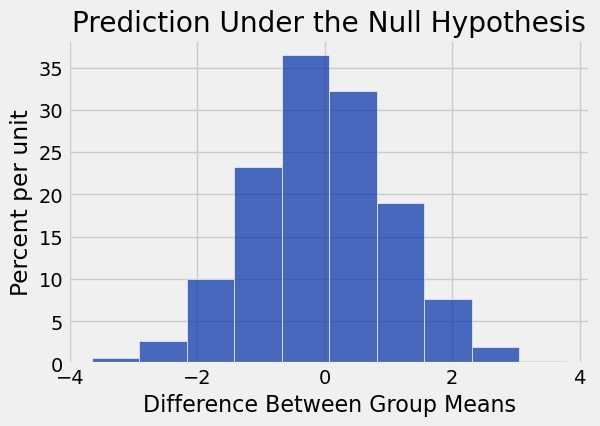

In [24]:
Table().with_column('Difference Between Group Means', differences).hist()
print('Observed Difference:', observed_difference)
plt.title('Prediction Under the Null Hypothesis');

In [25]:
repetitions = 2500

In [26]:
empirical_p = np.count_nonzero(differences <= observed_difference) / repetitions
empirical_p

0.0

---

### Conclusion

* With a p-value approximately 0%, we reject the null hypothesis and accept the alternative. 
* That is, in the population, the babies of the mothers who smoked during pregnancy weigh less, on average, than the babies of the non-smokers.

---

## Digital Experiments

---

* A/B tests are used in digital experiments. 
* Since they are typically easy to implement, it is common to find that multiple tests are actually run over a period of time.
* They can provide a methodical way to measure whether some new feature is having a statistically significant impact.
    * Advertising revenue
    * Click rate
    * etc.


<center>
    <a href="https://en.wikipedia.org/wiki/A/B_testing" title="Wikipedia - A/B Testing"><img src="./A-B_testing_example.png" alt="A comparision of two versions of a website design showing how the design might impact the click rate." width=60%></a>
</center>

---

# Causality

---

## Outline

* [Causality](#Causality)
* [An Error Probability](#An-Error-Probability)

### Randomized Controlled Experiment

* Sample A: control group
* Sample B: treatment group
* If the treatment and control groups are selected at random, then you can make causal conclusions.
* Any difference in outcomes between the two groups could be due to chance or the treatment.


---

### Randomized Control Experiment

* Load the data in `bta.csv` that is associated with [an experiment to assess whether or not Botox can be used to reduce pain](https://journals.lww.com/clinicalpain/Abstract/2006/01000/The_Effect_of_Small_Doses_of_Botulinum_Toxin_A_on.11.aspx) (Neck-Shoulder Myofascial Pain Syndrome). The control group received a saline solution, while the treatment group received botulinum toxin type A. A 1 result means that there was a reduction in pain, and a 0 result means that there wasn't a reduction in pain.
* Compare the results for the two groups.

In [27]:
botox = Table.read_table('bta.csv')
botox

Group,Result
Control,1
Control,1
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0


In [29]:
botox.group('Group', sum)

Group,Result sum
Control,2
Treatment,9


In [30]:
botox.group('Group', np.average)

Group,Result average
Control,0.125
Treatment,0.6


---

### Before the Randomization

* Population: All people who have neck pain
* Sample: 31 people from the population
    * 15 were **randomly** assigned to the treatment
    * 16 were **randomly** assigned to the control

```mermaid
graph LR
    A["Sample of Size 31"] -->|"Random Assigment"| B["16 Tickets - Control"] 
    B --> D{"Hypothesis Test"}
    C["15 tickets - Treatment"] --> D
    A -->|"Random Assigment"| C
```

_It was as if there were 15 tickets that said 'Treatment' and 16 that said 'Control' put into a hat and all subjects drew their group out of a hat._

---

### The Hypotheses

* Null: There is no difference between the treatment and the control in how they reduce neck pain.
* Alternative: The treatment (botox) has a positive effect on reducing neck pain.

---

### Random Assignment & Shuffling

<img src="./random_assignment_and_shuffling.png" width=80%>

---

## An Error Probability

---

### Can the Conclusion be Wrong?

* A **type I error** occurs when a null hypothesis which is true is rejected. This is also called a "false positive".
* A **type II error** occurs when a null hypothesis is not rejected when the null hypothesis is false. This is also called a "false negative".

| Null hypothesis is...| True | False | 
| --- | ----------- | ---|
| Rejected | Type I error | ✅ |
| Not rejected| ✅ | Type II error |

Example:
* Null hypothesis: Defendant is not guilty.
* Alternative hypothesis: Defendant is guilty.
* If an innocent person is found guilty and goes to jail, this is a type I error.
* If a guilty person is found innocent and goes free, this is a type II error.

---

### An Error Probability

* The cutoff for the p-value (**significance level**) is the type I error probability.
* If your cutoff is 5% and the null hypothesis happens to be true, then there is about a 5% chance that your test will reject the null hypothesis. (Type I Error: 5%)
* The chance of making a type II error is the complement value to the statistical power of the test. You are not expected to know about the power of a test or what the chance of making a type II error is in this class.

---

### Significance level vs p-value

* Significance level
    * Does not depend on observed data or simulation
    * Decide on it before seeing the results
    * Conventional values at 5% and 1%
    * Probability of hypothesis testing making a type I error
* p-value
    * Depends on the observed data and simulation
    * Probability under the null hypothesis that the test statistic is the observed value or further towards the alternative


## Hypothesis Test Concerns

The outcome of a hypothesis test can be affected by:
* The hypotheses you investigate: 
    * How do you define your null distribution?
* The test statistic you choose: 
    * How do you measure a difference between samples?
* The empirical distribution of the statistic under the null:
    * How many times do you simulate under the null distribution?
* The data you collected:
    * Did you happen to collect a sample that is similar to the population?
* The truth:
    * If the alternative hypothesis is true, how extreme is the difference?

---

## Hypothesis Test Effects

* Number of simulations: 
    * large as possible: empirical distribution → true distribution
    * No new data needs to be collected (yay!)
* Number of observations: 
    * A larger sample will lead you to reject the null more reliably if the alternative is in fact true.
* Difference from the null: 
    * If truth is similar to the null hypothesis, then even a large sample may not provide enough evidence to reject the null.


--- 

## Another Permutation Test

We can use the same method to compare other attributes of the smokers and the non-smokers, such as their ages. 

Histograms of the ages of the two groups show that in the sample, the mothers who smoked tended to be younger.

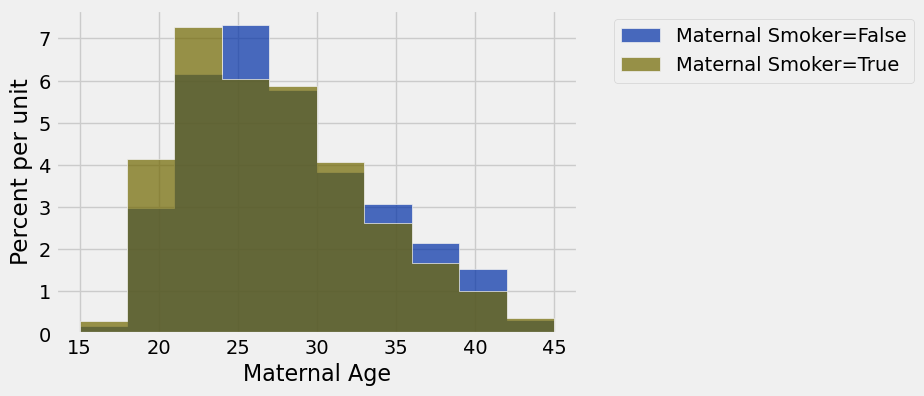

In [31]:
smoking_and_age = births.select('Maternal Smoker', 'Maternal Age')
smoking_and_age.hist('Maternal Age', group = 'Maternal Smoker')

In [32]:
def difference_of_means(table, group_label):
    """Takes: name of table,
    column label that indicates the group to which the row belongs
    Returns: Difference of mean ages of the two groups"""
    reduced = table.select('Maternal Age', group_label)
    means_table = reduced.group(group_label, np.average)
    means = means_table.column(1)
    return means.item(1) - means.item(0)

In [33]:
observed_age_difference = difference_of_means(births, 'Maternal Smoker')
observed_age_difference

-0.8076725017901509

Is this difference due to chance, or does it reflect an underlying difference in the population?


As before, we can use a permutation test to answer this question. If the underlying distributions of ages in the two groups are the same, then the empirical distribution of the difference based on permuted samples will predict how the statistic should vary due to chance.

We will follow the same process as in any simulation. We will start by writing a function that returns one simulated value of the difference between means, and then write a for loop to simulate numerous such values and collect them in an array.

In [34]:
  # array of shuffled labels
shuffled_labels = births.sample(with_replacement=False).column('Maternal Smoker')
shuffled_labels 

array([False,  True,  True, ...,  True, False,  True], dtype=bool)

In [35]:
 # table of ages and shuffled labels
shuffled_table = births.select('Maternal Age').with_column('Shuffled Label', shuffled_labels)
shuffled_table

Maternal Age,Shuffled Label
27,False
33,True
28,True
23,False
25,False
33,False
23,False
25,False
30,False
27,False


In [36]:
def one_simulated_difference_of_means():
    """Returns: Difference between mean ages
    of smokers and non-smokers after shuffling labels"""
    
    # array of shuffled labels
    shuffled_labels = births.sample(with_replacement=False).column('Maternal Smoker')
    
    # table of ages and shuffled labels
    shuffled_table = births.select('Maternal Age').with_column(
        'Shuffled Label', shuffled_labels)
    
    return difference_of_means(shuffled_table, 'Shuffled Label')  

In [37]:
age_differences = make_array()

repetitions = 5000
for i in np.arange(repetitions):
    new_difference = one_simulated_difference_of_means()
    age_differences = np.append(age_differences, new_difference)
age_differences

array([ 0.39786096, -0.18165364,  0.47298323, ...,  0.20468943,
       -0.00994561, -0.52149245])

Observed Difference: -0.8076725017901509


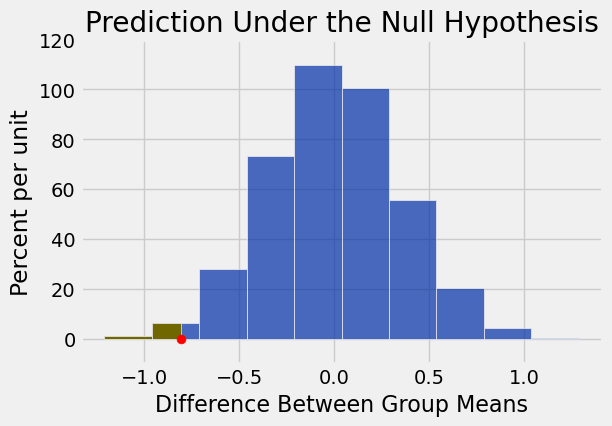

In [40]:
Table().with_column(
    'Difference Between Group Means', age_differences).hist(
    right_end = observed_age_difference)
# Plotting parameters; you can ignore the code below
plt.ylim(-0.1, 1.2)
plt.scatter(observed_age_difference, 0, color='red', s=40, zorder=3)
plt.title('Prediction Under the Null Hypothesis')
print('Observed Difference:', observed_age_difference)

In [41]:
empirical_p = np.count_nonzero(age_differences <= observed_age_difference) / 5000
empirical_p

0.0086

## Attribution

This content is licensed under the <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License (CC BY-NC-SA 4.0)</a> and derived from the <a href="https://www.data8.org/">Data 8: The Foundations of Data Science</a> offered by the University of California, Berkeley.

<img src="./by-nc-sa.png" width=100px>